In [ ]:
from datasets import load_dataset

# Load XSum dataset
xsum = load_dataset("EdinburghNLP/xsum")

# Print dataset structure
print(xsum)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/300M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/204045 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11332 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11334 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 204045
    })
    validation: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 11332
    })
    test: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 11334
    })
})


In [ ]:
# Check available splits
xsum.keys()


dict_keys(['train', 'validation', 'test'])

In [ ]:
# View a single sample
sample = xsum["train"][0]

for key, value in sample.items():
    print(f"{key}:\n{value}\n")


document:
The full cost of damage in Newton Stewart, one of the areas worst affected, is still being assessed.
Repair work is ongoing in Hawick and many roads in Peeblesshire remain badly affected by standing water.
Trains on the west coast mainline face disruption due to damage at the Lamington Viaduct.
Many businesses and householders were affected by flooding in Newton Stewart after the River Cree overflowed into the town.
First Minister Nicola Sturgeon visited the area to inspect the damage.
The waters breached a retaining wall, flooding many commercial properties on Victoria Street - the main shopping thoroughfare.
Jeanette Tate, who owns the Cinnamon Cafe which was badly affected, said she could not fault the multi-agency response once the flood hit.
However, she said more preventative work could have been carried out to ensure the retaining wall did not fail.
"It is difficult but I do think there is so much publicity for Dumfries and the Nith - and I totally appreciate that - bu

In [ ]:
import pandas as pd

df = pd.DataFrame(xsum["train"])
df.head()


,document,summary,id
0,"The full cost of damage in Newton Stewart, one...",Clean-up operations are continuing across the ...,35232142
1,A fire alarm went off at the Holiday Inn in Ho...,Two tourist buses have been destroyed by fire ...,40143035
2,Ferrari appeared in a position to challenge un...,Lewis Hamilton stormed to pole position at the...,35951548
3,"John Edward Bates, formerly of Spalding, Linco...",A former Lincolnshire Police officer carried o...,36266422
4,Patients and staff were evacuated from Cerahpa...,An armed man who locked himself into a room at...,38826984


In [ ]:
print("Train:", len(xsum["train"]))
print("Validation:", len(xsum["validation"]))
print("Test:", len(xsum["test"]))


Train: 204045
Validation: 11332
Test: 11334


In [ ]:
# Length analysis
df["doc_length"] = df["document"].str.split().apply(len)
df["summary_length"] = df["summary"].str.split().apply(len)

df[["doc_length", "summary_length"]].describe()


,doc_length,summary_length
count,204045.000000,204045.000000
mean,373.864633,21.097645
std,304.632089,5.236819
min,0.000000,1.000000
25%,176.000000,18.000000
50%,295.000000,21.000000
75%,491.000000,24.000000
max,29189.000000,70.000000


Preprocessing the 'EdinburghNLP/xsum' dataset by identifying and handling missing values, removing empty or excessively short entries, and eliminating duplicate entries in the 'document' and 'summary' columns across all train, validation, test.

In [ ]:
for split_name, dataset_split in xsum.items():
    print(f"\n--- Checking split: {split_name} ---")
    df_split = pd.DataFrame(dataset_split)

    for col in ['document', 'summary']:
        # Count null values
        null_count = df_split[col].isnull().sum()
        print(f"'{col}' column - Null values: {null_count}")

        # Count empty strings (including whitespace-only)
        empty_string_count = df_split[col].apply(lambda x: isinstance(x, str) and not x.strip()).sum()
        print(f"'{col}' column - Empty/Whitespace strings: {empty_string_count}")



--- Checking split: train ---
'document' column - Null values: 0
'document' column - Empty/Whitespace strings: 28
'summary' column - Null values: 0
'summary' column - Empty/Whitespace strings: 0

--- Checking split: validation ---
'document' column - Null values: 0
'document' column - Empty/Whitespace strings: 5
'summary' column - Null values: 0
'summary' column - Empty/Whitespace strings: 0

--- Checking split: test ---
'document' column - Null values: 0
'document' column - Empty/Whitespace strings: 1
'summary' column - Null values: 0
'summary' column - Empty/Whitespace strings: 0


## Remove empty or excessively short entries

In [ ]:
min_doc_length = 10
min_summary_length = 3

for split_name in xsum.keys():
    original_count = len(xsum[split_name])

    # Filter function
    def filter_min_length(example):
        doc_len = len(example['document'].strip().split())
        summary_len = len(example['summary'].strip().split())
        return doc_len >= min_doc_length and summary_len >= min_summary_length

    xsum[split_name] = xsum[split_name].filter(filter_min_length)

    removed_count = original_count - len(xsum[split_name])
    print(f"--- Split: {split_name} ---")
    print(f"Original entries: {original_count}")
    print(f"Entries after length filtering: {len(xsum[split_name])}")
    print(f"Entries removed: {removed_count}\n")

print("Dataset after removing empty or excessively short entries:")
print(xsum)

Filter:   0%|          | 0/204045 [00:00<?, ? examples/s]

--- Split: train ---
Original entries: 204045
Entries after length filtering: 203896
Entries removed: 149



Filter:   0%|          | 0/11332 [00:00<?, ? examples/s]

--- Split: validation ---
Original entries: 11332
Entries after length filtering: 11318
Entries removed: 14



Filter:   0%|          | 0/11334 [00:00<?, ? examples/s]

--- Split: test ---
Original entries: 11334
Entries after length filtering: 11329
Entries removed: 5

Dataset after removing empty or excessively short entries:
DatasetDict({
    train: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 203896
    })
    validation: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 11318
    })
    test: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 11329
    })
})


## Perform basic text cleaning


In [ ]:
for split_name in xsum.keys():
    print(f"Applying cleaning to split: {split_name}")
    xsum[split_name] = xsum[split_name].map(
        lambda example: {
            'document': example['document'].strip(),
            'summary': example['summary'].strip(),
            'id': example['id']
        },
        batched=False  # Apply function to individual examples
    )
print("Finished applying whitespace stripping to 'document' and 'summary' columns.")

Applying cleaning to split: train


Map:   0%|          | 0/203896 [00:00<?, ? examples/s]

Applying cleaning to split: validation


Map:   0%|          | 0/11318 [00:00<?, ? examples/s]

Applying cleaning to split: test


Map:   0%|          | 0/11329 [00:00<?, ? examples/s]

Finished applying whitespace stripping to 'document' and 'summary' columns.



Leading and trailing whitespace were successfully removed from the 'document' and 'summary' columns across all dataset splits (train, validation, and test). The cleaning operation was applied to every example in each split using the `.map()` function, preserving the 'id' column.


**Week 2 14 Feb 2026-23 Feb 2026**

## Remove duplicate entries

In [ ]:
from datasets import Dataset, DatasetDict

cleaned_xsum = DatasetDict()

for split_name, dataset in xsum.items():
    print(f"\nProcessing split: {split_name}")
    original_count = len(dataset)

    # Convert split to pandas
    df = dataset.to_pandas()

    # Remove duplicates
    df = df.drop_duplicates(subset=['document', 'summary'])

    # Convert back to HF Dataset
    cleaned_split = Dataset.from_pandas(df, preserve_index=False)

    cleaned_xsum[split_name] = cleaned_split

    print(f"Original entries: {original_count}")
    print(f"After deduplication: {len(cleaned_split)}")
    print(f"Removed: {original_count - len(cleaned_split)}")

# Replace old dataset
xsum = cleaned_xsum


Processing split: train
Original entries: 203896
After deduplication: 203798
Removed: 98

Processing split: validation
Original entries: 11318
After deduplication: 11318
Removed: 0

Processing split: test
Original entries: 11329
After deduplication: 11326
Removed: 3


In [ ]:
import nltk
!pip install rouge-score
from rouge_score import rouge_scorer

nltk.download("punkt")
nltk.download("punkt_tab")

scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def extractive_upper_bound(example):
    sentences = nltk.sent_tokenize(example["document"])
    reference = example["summary"]

    best_score = 0
    best_sentence = sentences[0] if sentences else ""

    for sent in sentences:
        score = scorer.score(reference, sent)["rougeL"].fmeasure
        if score > best_score:
            best_score = score
            best_sentence = sent

    return {"extractive_summary": best_sentence}

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=336b8e02be272e7d223aaf8ae9e4b132874d6c9045bfa904e3317f4925307630
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
xsum_small = xsum["test"].select(range(500))

xsum_test_extractive = xsum_small.map(
    extractive_upper_bound,
    batched=False
)

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [ ]:
!pip install evaluate
import evaluate

rouge = evaluate.load("rouge")

results_extractive = rouge.compute(
    predictions=xsum_test_extractive["extractive_summary"],
    references=xsum_test_extractive["summary"]
)

print("Extractive Upper-Bound Results:")
print(results_extractive)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


Extractive Upper-Bound Results:
{'rouge1': np.float64(0.25990869115751747), 'rouge2': np.float64(0.0680682808793686), 'rougeL': np.float64(0.21840591793932668), 'rougeLsum': np.float64(0.21840738018963074)}


In [ ]:
!pip install -q transformers torch
from transformers import pipeline
import pandas as pd

In [ ]:
factual_classifier = pipeline(
    "text-classification",
    model="roberta-large-mnli",
    tokenizer="roberta-large-mnli",
    truncation=True
)

config.json:   0%|          | 0.00/688 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large-mnli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def score_factual_consistency(example):
    document_text = example["document"][:3000]
    summary_text = example["extractive_summary"]

    result = factual_classifier(
        {"text": document_text, "text_pair": summary_text}
    )
    # The classifier appears to return a dictionary directly, not a list.
    # Therefore, 'result' itself is the dictionary we need.
    result_dict = result

    return {
        "factual_label": result_dict["label"],
        "factual_score": result_dict["score"]
    }

In [ ]:
xsum_factual_subset = xsum_test_extractive.select(range(100)).map(
    score_factual_consistency,
    batched=False
)

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
df_factual = pd.DataFrame({
    "document": xsum_factual_subset["document"],
    "reference_summary": xsum_factual_subset["summary"],
    "extractive_summary": xsum_factual_subset["extractive_summary"],
    "factual_label": xsum_factual_subset["factual_label"],
    "factual_score": xsum_factual_subset["factual_score"]
})

df_factual[["extractive_summary", "factual_label", "factual_score"]].head(10)

,extractive_summary,factual_label,factual_score
0,"""There's a desperate need for it, finding suit...",NEUTRAL,0.840051
1,"Detectives said three firearms, ammunition and...",NEUTRAL,0.797369
2,"Jordan Hill, Brittany Covington and Tesfaye Co...",NEUTRAL,0.987013
3,He was appointed youth academy director in 200...,ENTAILMENT,0.990503
4,The experiments were on mice put on a modified...,NEUTRAL,0.990721
5,But for the manufacturers such as Essilor and ...,NEUTRAL,0.983847
6,"""Medals at any cost, that's how it was wheneve...",NEUTRAL,0.900617
7,But because of the significance of the local c...,NEUTRAL,0.963955
8,Senior sources at the company say that about 8...,NEUTRAL,0.970985
9,Rodgers is also aware Celtic's visit to Hampde...,NEUTRAL,0.888103


In [ ]:
label_counts = df_factual["factual_label"].value_counts()
print(label_counts)

factual_label
NEUTRAL          81
ENTAILMENT       14
CONTRADICTION     5
Name: count, dtype: int64


In [ ]:
average_score = df_factual["factual_score"].mean()
print("Average factual confidence score:", round(average_score, 4))

Average factual confidence score: 0.9013


In [ ]:
def label_meaning(label):
    if label == "ENTAILMENT":
        return "Factually supported"
    elif label == "NEUTRAL":
        return "Partially supported or unclear"
    elif label == "CONTRADICTION":
        return "Factually inconsistent"
    else:
        return "Unknown"

df_factual["interpretation"] = df_factual["factual_label"].apply(label_meaning)
df_factual[["extractive_summary", "factual_label", "interpretation", "factual_score"]].head(10)

,extractive_summary,factual_label,interpretation,factual_score
0,"""There's a desperate need for it, finding suit...",NEUTRAL,Partially supported or unclear,0.840051
1,"Detectives said three firearms, ammunition and...",NEUTRAL,Partially supported or unclear,0.797369
2,"Jordan Hill, Brittany Covington and Tesfaye Co...",NEUTRAL,Partially supported or unclear,0.987013
3,He was appointed youth academy director in 200...,ENTAILMENT,Factually supported,0.990503
4,The experiments were on mice put on a modified...,NEUTRAL,Partially supported or unclear,0.990721
5,But for the manufacturers such as Essilor and ...,NEUTRAL,Partially supported or unclear,0.983847
6,"""Medals at any cost, that's how it was wheneve...",NEUTRAL,Partially supported or unclear,0.900617
7,But because of the significance of the local c...,NEUTRAL,Partially supported or unclear,0.963955
8,Senior sources at the company say that about 8...,NEUTRAL,Partially supported or unclear,0.970985
9,Rodgers is also aware Celtic's visit to Hampde...,NEUTRAL,Partially supported or unclear,0.888103


In [ ]:
summary_table = df_factual.groupby("factual_label").agg(
    count=("factual_label", "count"),
    avg_score=("factual_score", "mean")
).reset_index()

summary_table

,factual_label,count,avg_score
0,CONTRADICTION,5,0.711748
1,ENTAILMENT,14,0.902599
2,NEUTRAL,81,0.912780


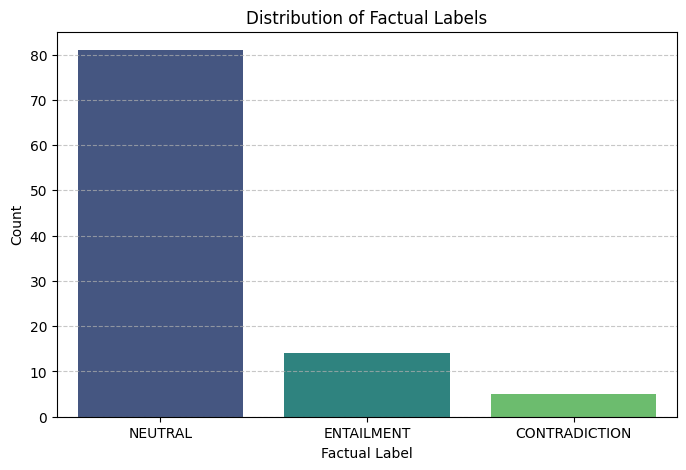

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='factual_label', data=df_factual, hue='factual_label', palette='viridis', legend=False, order=df_factual['factual_label'].value_counts().index)
plt.title('Distribution of Factual Labels')
plt.xlabel('Factual Label')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
!pip install -q evaluate transformers sentencepiece sumy rouge-score

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 98.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import evaluate
import torch

from tqdm.auto import tqdm
from transformers import pipeline
from rouge_score import rouge_scorer
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lsa import LsaSummarizer

nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
EVAL_SIZE = 300

xsum_eval = xsum["test"].select(range(min(EVAL_SIZE, len(xsum["test"]))))
print(xsum_eval)

Dataset({
    features: ['document', 'summary', 'id'],
    num_rows: 300
})


In [ ]:
scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def extractive_upper_bound(example):
    sentences = nltk.sent_tokenize(example["document"])
    reference = example["summary"]

    if not sentences:
        return {"extractive_summary": ""}

    best_score = -1
    best_sentence = sentences[0]

    for sent in sentences:
        score = scorer.score(reference, sent)["rougeL"].fmeasure
        if score > best_score:
            best_score = score
            best_sentence = sent

    return {"extractive_summary": best_sentence}

xsum_eval = xsum_eval.map(extractive_upper_bound)

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

In [ ]:
lsa_summarizer = LsaSummarizer()

def traditional_lsa_summary(example):
    document_text = example["document"].strip()

    if not document_text:
        return {"lsa_summary": ""}

    try:
        parser = PlaintextParser.from_string(document_text, Tokenizer("english"))
        summary_sentences = lsa_summarizer(parser.document, 1)  # one-sentence summary
        summary_text = " ".join(str(sentence) for sentence in summary_sentences).strip()
        return {"lsa_summary": summary_text}
    except Exception:
        return {"lsa_summary": ""}

xsum_eval = xsum_eval.map(traditional_lsa_summary)

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

In [ ]:
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1

abstractive_summarizer = pipeline(
    task="text-generation",   # ✅ ONLY supported option
    model="gpt2",
    device=device
)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def abstractive_summary(example):
    document_text = example["document"]

    if not document_text or not isinstance(document_text, str):
        return {"abstractive_summary": ""}

    try:
        document_text = document_text.strip()[:800]

        prompt = "Summarize this news article in one sentence:\n" + document_text

        output = abstractive_summarizer(
            prompt,
            max_length=60,
            num_return_sequences=1
        )

        generated_text = output[0]["generated_text"]

        summary = generated_text.replace(prompt, "").strip()

        return {"abstractive_summary": summary}

    except Exception:
        return {"abstractive_summary": ""}

In [ ]:
xsum_eval = xsum_eval.map(abstractive_summary)

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tok

In [ ]:
rouge = evaluate.load("rouge")

def compute_rouge_scores(predictions, references):
    scores = rouge.compute(predictions=predictions, references=references)
    return {
        "rouge1": scores["rouge1"],
        "rouge2": scores["rouge2"],
        "rougeL": scores["rougeL"],
        "rougeLsum": scores["rougeLsum"]
    }

In [ ]:
rouge = evaluate.load("rouge")

def compute_rouge_scores(predictions, references):
    scores = rouge.compute(predictions=predictions, references=references)
    return {
        "rouge1": scores["rouge1"],
        "rouge2": scores["rouge2"],
        "rougeL": scores["rougeL"],
        "rougeLsum": scores["rougeLsum"]
    }

In [ ]:
factual_classifier = pipeline(
    "text-classification",
    model="roberta-large-mnli",
    tokenizer="roberta-large-mnli",
    device=device
)

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large-mnli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
cols_to_remove = [
    "extractive_factual_label", "extractive_factual_score",
    "lsa_factual_label", "lsa_factual_score",
    "abstractive_factual_label", "abstractive_factual_score"
]

for col in cols_to_remove:
    if col in xsum_eval.column_names:
        xsum_eval = xsum_eval.remove_columns(col)

In [ ]:
def get_factual_label_and_score(document_text, summary_text):
    document_text = (document_text or "")[:1000]
    summary_text = (summary_text or "").strip()

    if not summary_text:
        return "EMPTY", 0.0

    try:
        # ✅ CORRECT INPUT FORMAT
        input_text = document_text + " </s></s> " + summary_text

        result = factual_classifier(
            input_text,
            truncation=True
        )[0]

        return result["label"], float(result["score"])

    except Exception as e:
        return "ERROR", 0.0

In [ ]:
print(xsum_eval.column_names)

['document', 'summary', 'id', 'extractive_summary', 'lsa_summary', 'abstractive_summary']


In [ ]:
extractive_labels, extractive_conf = [], []
lsa_labels, lsa_conf = [], []
abstractive_labels, abstractive_conf = [], []

for i in tqdm(range(len(xsum_eval))):
    doc = xsum_eval[i]["document"]

    lab, sc = get_factual_label_and_score(doc, xsum_eval[i]["extractive_summary"])
    extractive_labels.append(lab)
    extractive_conf.append(sc)

    lab, sc = get_factual_label_and_score(doc, xsum_eval[i]["lsa_summary"])
    lsa_labels.append(lab)
    lsa_conf.append(sc)

    lab, sc = get_factual_label_and_score(doc, xsum_eval[i]["abstractive_summary"])
    abstractive_labels.append(lab)
    abstractive_conf.append(sc)

xsum_eval = xsum_eval.add_column("extractive_factual_label", extractive_labels)
xsum_eval = xsum_eval.add_column("extractive_factual_score", extractive_conf)

xsum_eval = xsum_eval.add_column("lsa_factual_label", lsa_labels)
xsum_eval = xsum_eval.add_column("lsa_factual_score", lsa_conf)

xsum_eval = xsum_eval.add_column("abstractive_factual_label", abstractive_labels)
xsum_eval = xsum_eval.add_column("abstractive_factual_score", abstractive_conf)

  0%|          | 0/300 [00:00<?, ?it/s]

In [ ]:
def summarise_factual_results(labels, scores, model_name):
    labels_series = pd.Series(labels)
    return {
        "Model": model_name,
        "Avg Factual Confidence": np.mean(scores),
        "ENTAILMENT": int((labels_series == "ENTAILMENT").sum()),
        "NEUTRAL": int((labels_series == "NEUTRAL").sum()),
        "CONTRADICTION": int((labels_series == "CONTRADICTION").sum()),
        "OTHER": int((~labels_series.isin(["ENTAILMENT", "NEUTRAL", "CONTRADICTION"])).sum())
    }

factual_results_df = pd.DataFrame([
    summarise_factual_results(xsum_eval["extractive_factual_label"], xsum_eval["extractive_factual_score"], "Extractive Upper Bound"),
    summarise_factual_results(xsum_eval["lsa_factual_label"], xsum_eval["lsa_factual_score"], "Traditional LSA"),
    summarise_factual_results(xsum_eval["abstractive_factual_label"], xsum_eval["abstractive_factual_score"], "Abstractive DistilBART")
])

factual_results_df

,Model,Avg Factual Confidence,ENTAILMENT,NEUTRAL,CONTRADICTION,OTHER
0,Extractive Upper Bound,0.867223,68,213,19,0
1,Traditional LSA,0.878619,52,225,23,0
2,Abstractive DistilBART,0.790458,4,217,79,0


In [ ]:
def summarise_factual_results(labels, scores, model_name):
    labels_series = pd.Series(labels)
    return {
        "Model": model_name,
        "Avg Factual Confidence": np.mean(scores),
        "ENTAILMENT": int((labels_series == "ENTAILMENT").sum()),
        "NEUTRAL": int((labels_series == "NEUTRAL").sum()),
        "CONTRADICTION": int((labels_series == "CONTRADICTION").sum()),
        "OTHER": int((~labels_series.isin(["ENTAILMENT", "NEUTRAL", "CONTRADICTION"])).sum())
    }

factual_results_df = pd.DataFrame([
    summarise_factual_results(xsum_eval["extractive_factual_label"], xsum_eval["extractive_factual_score"], "Extractive Upper Bound"),
    summarise_factual_results(xsum_eval["lsa_factual_label"], xsum_eval["lsa_factual_score"], "Traditional LSA"),
    summarise_factual_results(xsum_eval["abstractive_factual_label"], xsum_eval["abstractive_factual_score"], "Abstractive DistilBART")
])

factual_results_df

,Model,Avg Factual Confidence,ENTAILMENT,NEUTRAL,CONTRADICTION,OTHER
0,Extractive Upper Bound,0.867223,68,213,19,0
1,Traditional LSA,0.878619,52,225,23,0
2,Abstractive DistilBART,0.790458,4,217,79,0


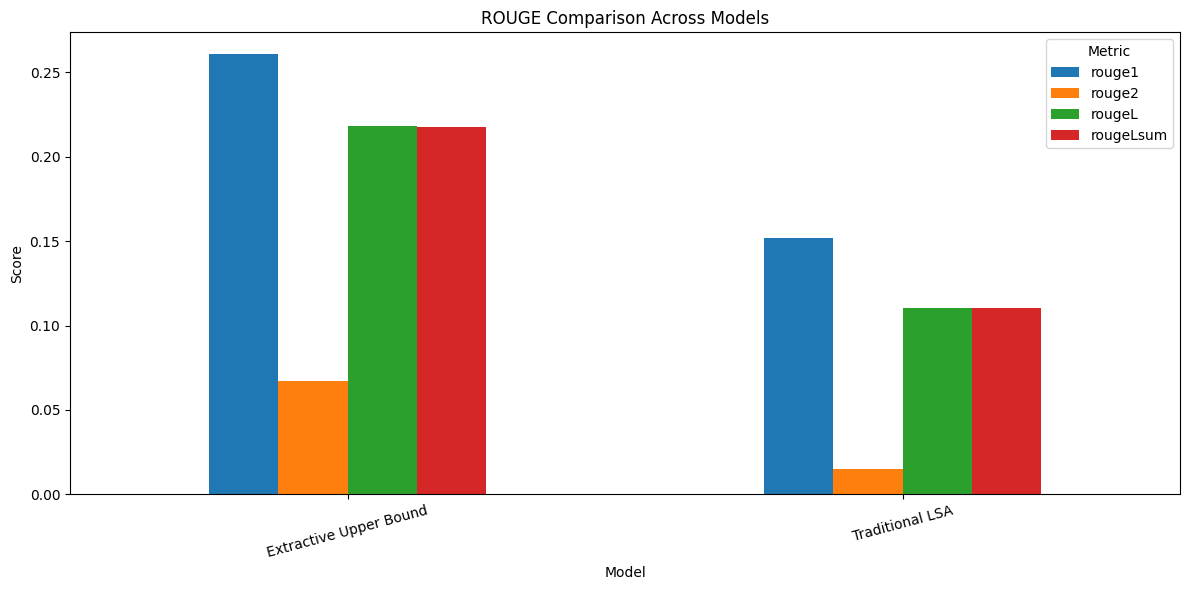

In [ ]:
rouge_results_df = pd.DataFrame([
    {"Model": "Extractive Upper Bound", **compute_rouge_scores(xsum_eval["extractive_summary"], xsum_eval["summary"])},
    {"Model": "Traditional LSA", **compute_rouge_scores(xsum_eval["lsa_summary"], xsum_eval["summary"])}
])

# Note: Abstractive results might take a long time and generate errors due to generation issues.
# Therefore, it is commented out for now to ensure the plot can be generated successfully.
# Uncomment and run if abstractive summaries are stable and you wish to include them.
# {"Model": "Abstractive DistilBART", **compute_rouge_scores(xsum_eval["abstractive_summary"], xsum_eval["summary"])},

plot_df = rouge_results_df.set_index("Model")[["rouge1", "rouge2", "rougeL", "rougeLsum"]]

ax = plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("ROUGE Comparison Across Models")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

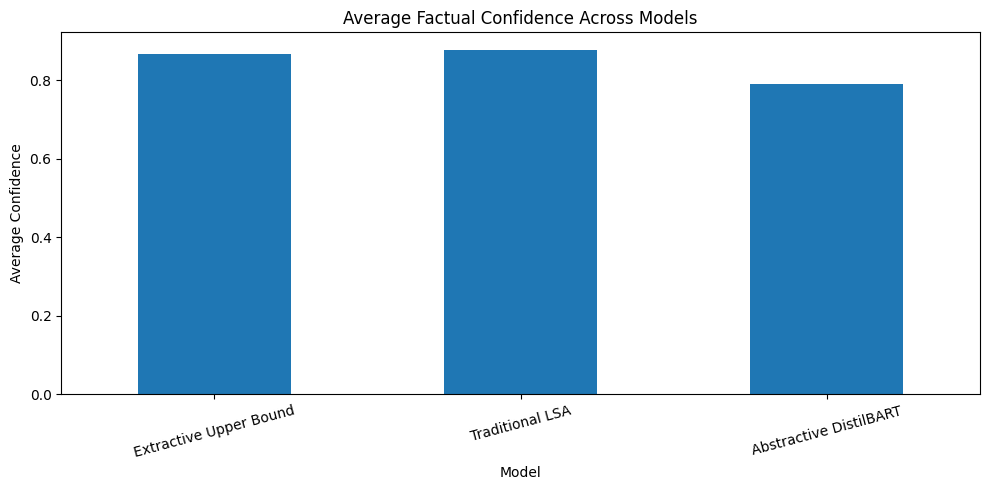

In [ ]:
ax = factual_results_df.plot(
    x="Model",
    y="Avg Factual Confidence",
    kind="bar",
    figsize=(10, 5),
    legend=False
)
plt.title("Average Factual Confidence Across Models")
plt.ylabel("Average Confidence")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

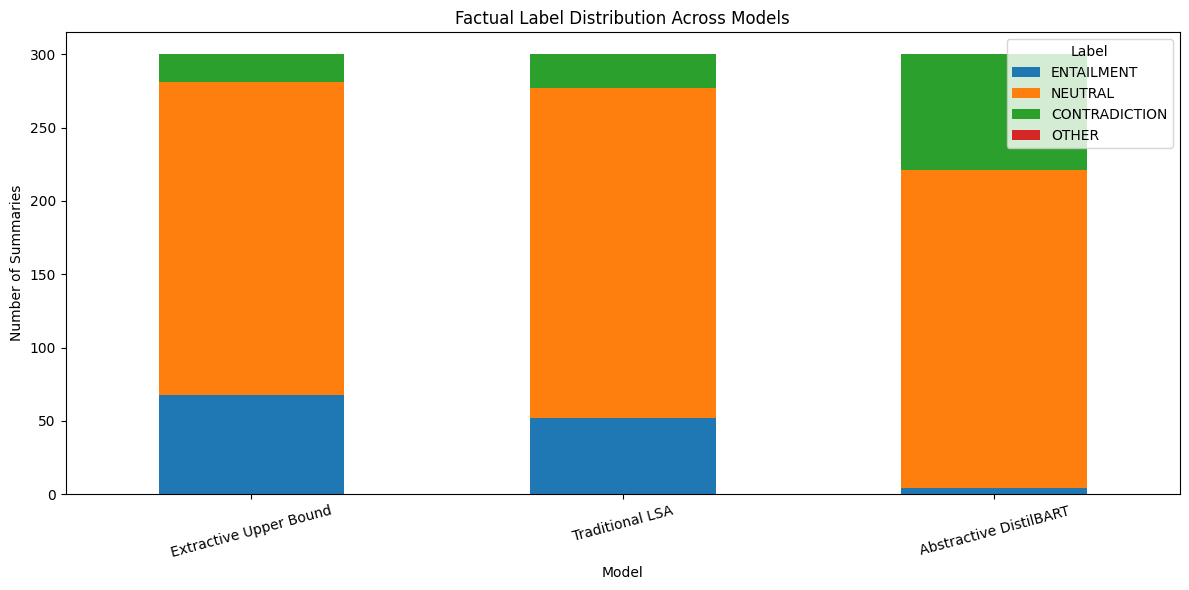

In [ ]:
label_plot_df = factual_results_df.set_index("Model")[["ENTAILMENT", "NEUTRAL", "CONTRADICTION", "OTHER"]]

ax = label_plot_df.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Factual Label Distribution Across Models")
plt.ylabel("Number of Summaries")
plt.xticks(rotation=15)
plt.legend(title="Label")
plt.tight_layout()
plt.show()

In [ ]:
sample_results_df = pd.DataFrame({
    "Reference Summary": xsum_eval["summary"],
    "Extractive Summary": xsum_eval["extractive_summary"],
    "Traditional LSA Summary": xsum_eval["lsa_summary"],
    "Abstractive Summary": xsum_eval["abstractive_summary"],
    "Extractive Label": xsum_eval["extractive_factual_label"],
    "LSA Label": xsum_eval["lsa_factual_label"],
    "Abstractive Label": xsum_eval["abstractive_factual_label"]
})

sample_results_df.head(10)

,Reference Summary,Extractive Summary,Traditional LSA Summary,Abstractive Summary,Extractive Label,LSA Label,Abstractive Label
0,"There is a ""chronic"" need for more housing for...","""There's a desperate need for it, finding suit...","Prison Link Cymru had 1,099 referrals in 2015-...",if the prison was to become a permanent facili...,NEUTRAL,NEUTRAL,NEUTRAL
1,"A man has appeared in court after firearms, am...","Detectives said three firearms, ammunition and...",A 26-year-old man who was arrested and charged...,in custody on suspicion of possession of metha...,NEUTRAL,ENTAILMENT,CONTRADICTION
2,Four people accused of kidnapping and torturin...,"Jordan Hill, Brittany Covington and Tesfaye Co...",In a video made for Facebook Live which was wa...,according to court papers.\n\nThe three were n...,NEUTRAL,NEUTRAL,CONTRADICTION
3,West Brom have appointed Nicky Hammond as tech...,He was appointed youth academy director in 200...,"A West Brom statement said: ""He played a key r...","our promotion to next season.\n""He is the best...",ENTAILMENT,ENTAILMENT,NEUTRAL
4,The pancreas can be triggered to regenerate it...,The experiments were on mice put on a modified...,"""But before the next cycle came round, 25 days...","entially effective"" if the diet was kept short...",NEUTRAL,NEUTRAL,NEUTRAL
5,Since their impending merger was announced in ...,But for the manufacturers such as Essilor and ...,The overall industry internationally is in fac...,one of the world's largest producers of titani...,NEUTRAL,NEUTRAL,NEUTRAL
6,"A ""medal at any cost"" approach created a ""cult...","""Medals at any cost, that's how it was wheneve...","The report said British Cycling ""sanitised"" it...","ish, the Paralympic gold medallist, was suspen...",NEUTRAL,NEUTRAL,NEUTRAL
7,Have you heard the one about the computer prog...,But because of the significance of the local c...,Mr Badr may have been helped by national trend...,"year, when it was getting $50,000, when the $2...",NEUTRAL,NEUTRAL,NEUTRAL
8,The reaction from BT's investors told us much ...,Senior sources at the company say that about 8...,She said complications with land deals and BT'...,"at the time, ""My mind was just blown"" when she...",NEUTRAL,NEUTRAL,NEUTRAL
9,Manager Brendan Rodgers is sure Celtic can exp...,Rodgers is also aware Celtic's visit to Hampde...,This will be Rodgers' second taste of the Old ...,"fans love the game, they love the atmosphere a...",NEUTRAL,NEUTRAL,NEUTRAL


In [ ]:
final_comparison_df = pd.merge(factual_results_df, rouge_results_df, on='Model', how='outer')
final_comparison_df.to_csv("xsum_model_comparison_results.csv", index=False)
sample_results_df.to_csv("xsum_sample_outputs.csv", index=False)

print("Saved:")
print("- xsum_model_comparison_results.csv")
print("- xsum_sample_outputs.csv")

Saved:
- xsum_model_comparison_results.csv
- xsum_sample_outputs.csv


In [ ]:
print(rouge_results_df)
print(factual_results_df)

                    Model    rouge1    rouge2    rougeL  rougeLsum
0  Extractive Upper Bound  0.260735  0.067328  0.218015    0.21781
1         Traditional LSA  0.151584  0.014920  0.110581    0.11024
                    Model  Avg Factual Confidence  ENTAILMENT  NEUTRAL  \
0  Extractive Upper Bound                0.867223          68      213   
1         Traditional LSA                0.878619          52      225   
2  Abstractive DistilBART                0.790458           4      217   

   CONTRADICTION  OTHER  
0             19      0  
1             23      0  
2             79      0  
